# Model

The `Model` class connects a simulator to its `JointPrior`. It draws parameter values, broadcasts time-invariant values across steps, calls the simulator in batches, and returns observations and parameters in one named dictionary. It can also apply optional contamination and missingness processes.

## Example

We continue with the DDM example. The prior lets drift rate, boundary separation, and non-decision time vary independently across observations, while starting bias stays fixed.

In [ ]:
import superstats as sup

In [3]:
simulator = sup.simulation.sample_ddm

In [4]:
prior = sup.JointPrior(
    v=sup.transition.RandomWalk(),
    a=sup.transition.RandomWalk(),
    tau=sup.transition.RandomWalk(),
    bias=0.5,
)

In [5]:
model = sup.Model(
    simulator=simulator,
    prior=prior,
    link_function={
        "v": sup.LinkFunction(bounds=(0.0, 6.0)),
        "a": sup.LinkFunction(bounds=(0.2, 4.0)),
        "tau": sup.LinkFunction(bounds=(0.0, 2.0)),
    },
    missing=None,
    contamination=None,
)

This example disables both augmentation processes. This is explicit because `Model` otherwise defaults to `missing="random"`. We now draw 100 independent parameter configurations and simulate a 200-observation sequence from each.

## Link Functions

Transitions and parameter formulas operate on an unconstrained scale. The `link_function` argument tells `Model` how to transform those raw values into valid simulator parameters. Links are applied after trajectories, formulas, and parameter-valued context have been resolved, and immediately before the simulator is called. Each mapping key therefore names a final simulator parameter such as `v` or `a`, not a transition hyperparameter or regression coefficient. Parameters omitted from the mapping are passed through unchanged.

`LinkFunction` supports the following named transformations:

| Link | Domain | Typical use |
|---|---|---|
| `LinkFunction("scaled_sigmoid", bounds=(lower, upper))` | Finite interval | Smoothly bounded stochastic trajectories |
| `LinkFunction("clip", bounds=(lower, upper))` | Finite interval | Deterministic trajectories that should remain unchanged inside the interval |
| `LinkFunction("softplus")` | Positive values | Positive parameters without a finite upper bound |
| `LinkFunction("exp")` | Positive values | Exponential-scale parameters |
| `LinkFunction("identity")` | Unconstrained | Parameters that need no transformation |

As a practical default, use a scaled sigmoid with sensible bounds for stochastic trajectories and hard clipping with sensible bounds for deterministic trajectories.

Links change what the simulator receives, not what the posterior approximator learns. `Model.sample()` returns stochastic and reconstructed deterministic trajectories on their raw scale, together with the raw coefficients and transition hyperparameters used as inference targets, while the simulator receives the linked parameter values. This keeps inference unconstrained and makes posterior resimulation apply the same link consistently. `Model.sample_prior()["model_params"]` can be used to inspect the linked parameters directly. Prior plots remain on the raw scale; prior push-forward plots show the consequences of the linked values in simulated observations.

## Synthetic data generation

In [6]:
sim_data = model.sample(
    batch_size=100,
    num_steps=200,
)

print(sim_data.keys())

dict_keys(['response_time', 'choice', 'time_steps', 'v', 'a', 'tau', 'v_sigma', 'a_sigma', 'tau_sigma'])


Every observation and parameter has its own dictionary key. Here, `response_time`, `choice`, and `time_steps` have shape `(100, 200)`. The local parameters `v`, `a`, and `tau` have shape `(100, 200, 1)` on their raw inference scale, while their transition scales have shape `(100, 1)`. The DDM receives the linked versions of `v`, `a`, and `tau`. The fixed `bias` is used by the simulator but is not returned as an inference target.

## Prior Push-forward Checks

Before training, check whether the combined prior and simulator generate credible observations. A prior push-forward check can reveal impossible values, excessive variability, unrealistic tails, or temporal patterns that do not match domain knowledge. Revise the model assumptions when it fails; more neural-network training cannot repair an implausible generative model.

Simulate five datasets (`batch_size=5`) each with 200 observations (`num_steps=200`) and plot per dataset (`aggregation=None`) response time (`data_dim=0`) distributions (`kind="dist"`).

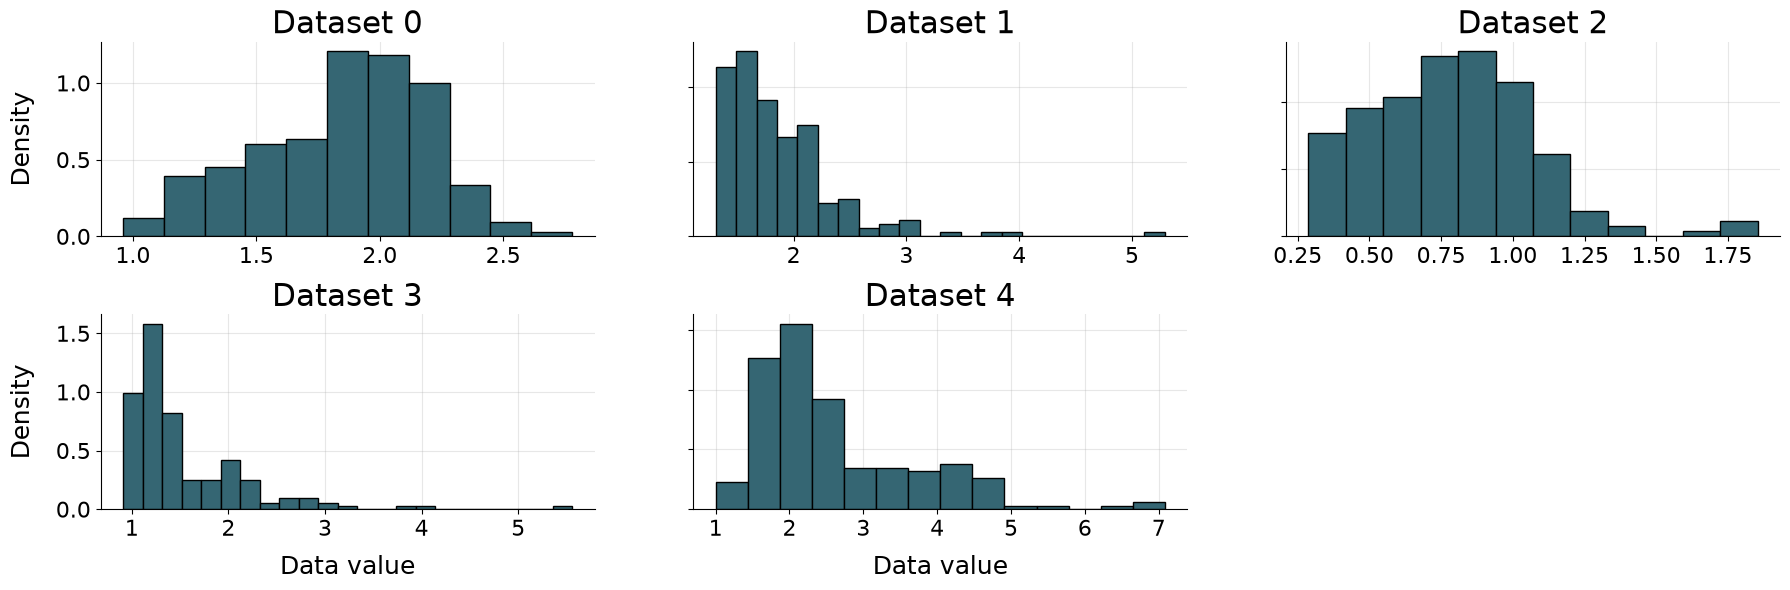

In [7]:
fig = model.plot_push_forward(
    batch_size=5,
    num_steps=200,
    data_dim="response_time",
    kind="dist",
    dist_type="hist",
    aggregation=None,
)

Alternatively, we can plot choices (`data_dim=1`) as time series (`kind="time_series"`) aggregated across datasets by median (`aggregation=np.median`). Additionally, we depict variation as standard deviation (`uncertainty_fun="std"`), show individual datasets (`spaggetti=True`), and display the marginal distribution (`marginal=True`) as a kernel density (`dist_type="kde"`).

Disclaimer: we could choose better settings for plotting push forward checks for choices. Here, I simply wanted to demonstrate the flexible possibilities of the `plot_push_forward()` method.

In [8]:
import numpy as np

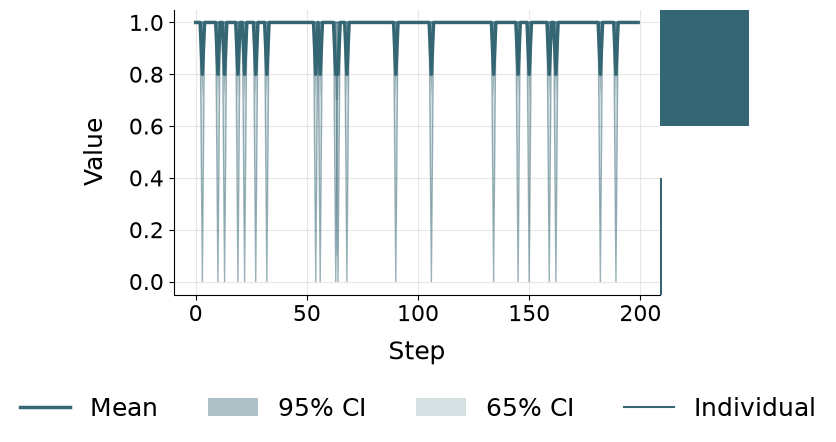

In [9]:
fig = model.plot_push_forward(
    batch_size=5,
    num_steps=200,
    data_dim="choice",
    kind="time_series",
    aggregation=np.mean,
    uncertainty_fun="ci",
    spaghetti=True,
    marginal=True,
    dist_type="kde",
)